In [ ]:
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix

In [37]:
df = pd.read_csv('datasets/Dataset_Reponse_Marketing.csv')

print(df.head())
print(df.info())

   Age   Sexe  Revenu_annuel  Temps_passe_sur_site  Achats_en_ligne  \
0   22  Homme          40124             16.518974                9   
1   32  Femme          26307             21.973535                8   
2   28  Femme          30040             26.762915                9   
3   16  Femme          15843             29.046008                9   
4   45  Homme          20225             21.479944                5   

   Reponse_campagne  
0                 1  
1                 1  
2                 1  
3                 0  
4                 0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   2400 non-null   int64  
 1   Sexe                  2400 non-null   object 
 2   Revenu_annuel         2400 non-null   int64  
 3   Temps_passe_sur_site  2400 non-null   float64
 4   Achats_en_ligne       24

In [38]:
df['Sexe'] = df['Sexe'].map({'Homme': 0, 'Femme': 1})

# Séparation des features et de la cible
X = df.drop(columns='Reponse_campagne')
y = df['Reponse_campagne']

# Normalisation StandardScaler
features_to_scale = ['Age', 'Revenu_annuel', 'Temps_passe_sur_site', 'Achats_en_ligne']
scaler = StandardScaler()
X[features_to_scale] = scaler.fit_transform(X[features_to_scale])

# Split train/test stratifié (garder la meme proportion des classes dans train et test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

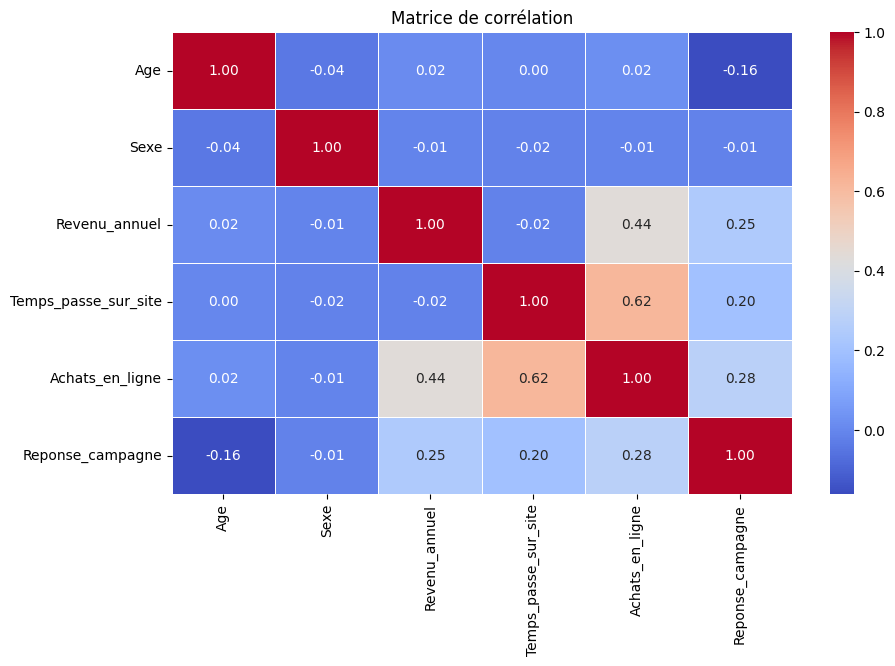

In [39]:
# Matrice de corrélation
corr_matrix = df.corr(numeric_only=True)

# Affichage heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation")
plt.show()

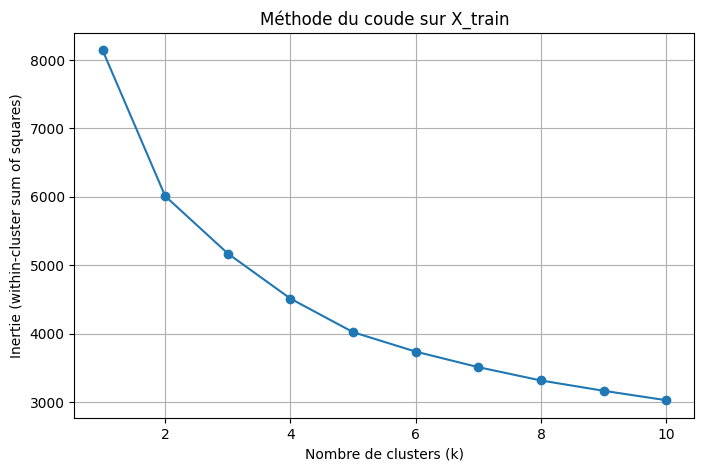

In [40]:
# Elbow method : inertie pour différents k
inertias = []
k_range = range(1, 11)


for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_train)
    inertias.append(kmeans.inertia_)

# Affichage de la courbe du coude
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie (within-cluster sum of squares)")
plt.title("Méthode du coude sur X_train")
plt.grid(True)
plt.show()

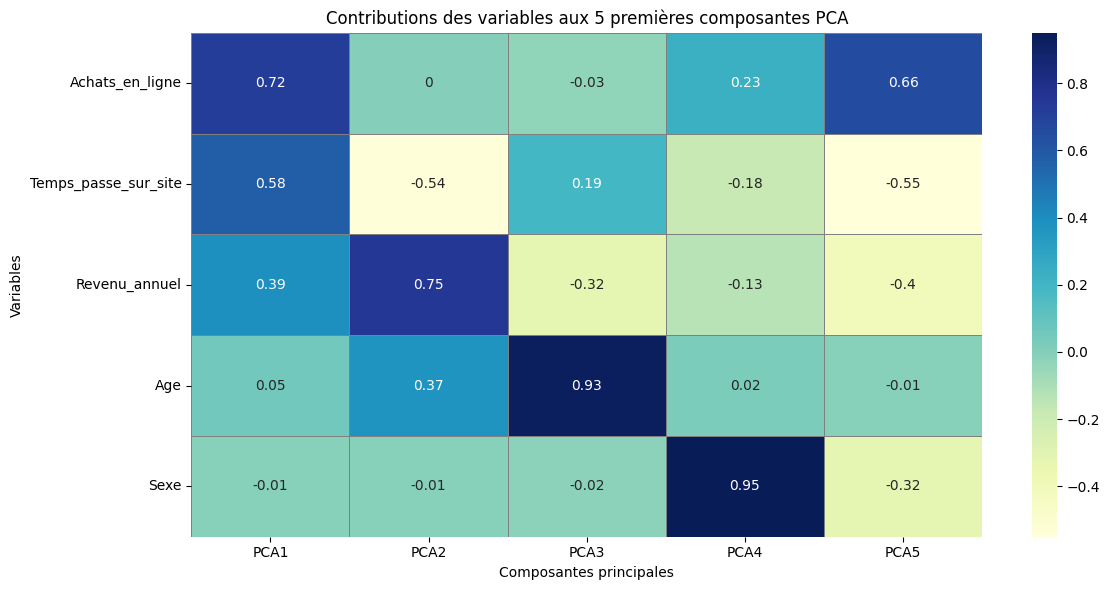

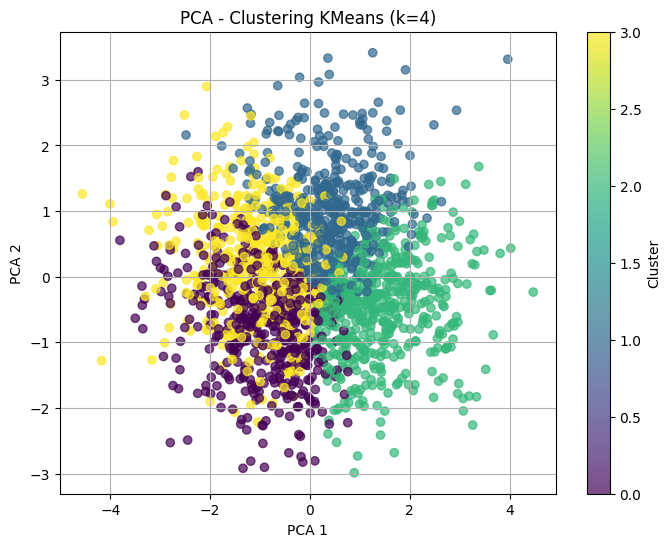

Matrice de passage (clusters vs réponse réelle) :

Vraie_classe    0    1
Cluster               
0             232  222
1             164  324
2             180  337
3             334  127


In [46]:
# ----- K-Means avec k=4 -----
k = 4
kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_train)

# ----- PCA -----
pca = PCA()
X_pca = pca.fit_transform(X_train)

# Création du DataFrame des charges (loadings)
pca_loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PCA{i+1}' for i in range(pca.n_components_)],
    index=X_train.columns
)

# Tri facultatif des features par importance absolue sur la 1ère composante
pca_sorted = pca_loadings.copy()
pca_sorted['|PCA1|'] = pca_sorted['PCA1'].abs()
pca_sorted = pca_sorted.sort_values(by='|PCA1|', ascending=False).drop(columns='|PCA1|')

# Affichage propre sous forme de heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pca_sorted.iloc[:, :5].round(2), annot=True, cmap="YlGnBu", linewidths=0.5, linecolor='gray')
plt.title("Contributions des variables aux 5 premières composantes PCA")
plt.xlabel("Composantes principales")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

# ----- Visualisation des clusters -----
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.7)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title(f"PCA - Clustering KMeans (k={k})")
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()

# ----- Matrice de passage -----
df_clusters = pd.DataFrame({'Cluster': clusters, 'Vraie_classe': y_train.reset_index(drop=True)})
matrice_passage = pd.crosstab(df_clusters['Cluster'], df_clusters['Vraie_classe'])
print("Matrice de passage (clusters vs réponse réelle) :\n")
print(matrice_passage)

Rapport de classification :

              precision    recall  f1-score   support

           0       0.66      0.60      0.63       227
           1       0.67      0.72      0.69       253

    accuracy                           0.66       480
   macro avg       0.66      0.66      0.66       480
weighted avg       0.66      0.66      0.66       480



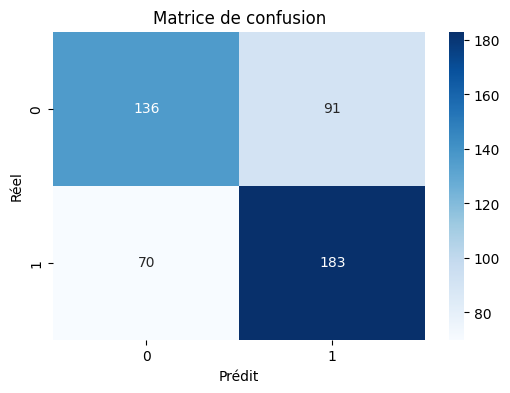

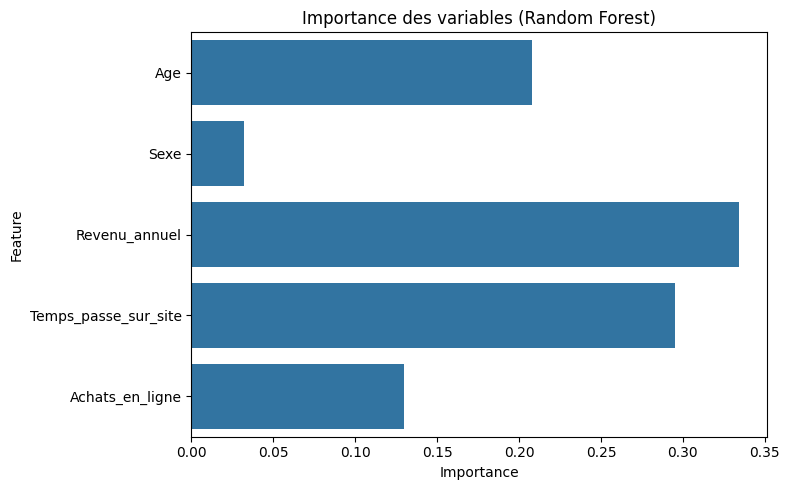

In [42]:
# Entraînement du modèle
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Prédictions
y_pred = rf.predict(X_test)

# Rapport de classification
print("Rapport de classification :\n")
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()

# Importance des features
importances = rf.feature_importances_
features = X_train.columns
plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=features)
plt.title("Importance des variables (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [ ]:
# ----- Entraînement -----
model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)
model.fit(X_train, y_train)

# ----- Prédictions -----
y_pred = model.predict(X_test)

# ----- Évaluation -----
print("Rapport de classification :")
print(classification_report(y_test, y_pred))

# ----- Matrice de confusion -----
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion - XGBoost")
plt.tight_layout()
plt.show()

# ----- Importance des variables -----
xgb.plot_importance(model, max_num_features=10, importance_type='gain')
plt.title("Top features - XGBoost")
plt.tight_layout()
plt.show()